In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from matplotlib.lines import Line2D
import matplotlib
#matplotlib.use("tkAgg")

# Filtering the data

In [2]:

# Loading the CSV
df = pd.read_csv('data\data_suicide\suicide.csv', encoding='utf-8')

# FILTERING
# Drop rows with missing or unreliable data
df = df[df['FLAG'].isna()]  # Only keep rows where FLAG is NaN and not ...
df = df[df['YEAR'] >= 1980] # Filter out years before 1980

print(df.head())

                                                UNIT STUB_NAME   STUB_LABEL  \
3  Deaths per 100,000 resident population, age-ad...     Total  All persons   
4  Deaths per 100,000 resident population, age-ad...     Total  All persons   
5  Deaths per 100,000 resident population, age-ad...     Total  All persons   
6  Deaths per 100,000 resident population, age-ad...     Total  All persons   
7  Deaths per 100,000 resident population, age-ad...     Total  All persons   

   YEAR  ESTIMATE FLAG  
3  1980      12.2  NaN  
4  1981      12.3  NaN  
5  1982      12.5  NaN  
6  1983      12.4  NaN  
7  1984      12.6  NaN  


# Ex2: Visualisation of Crude and age-adjusted results for sex only


dual axis female and male
male one saide female other

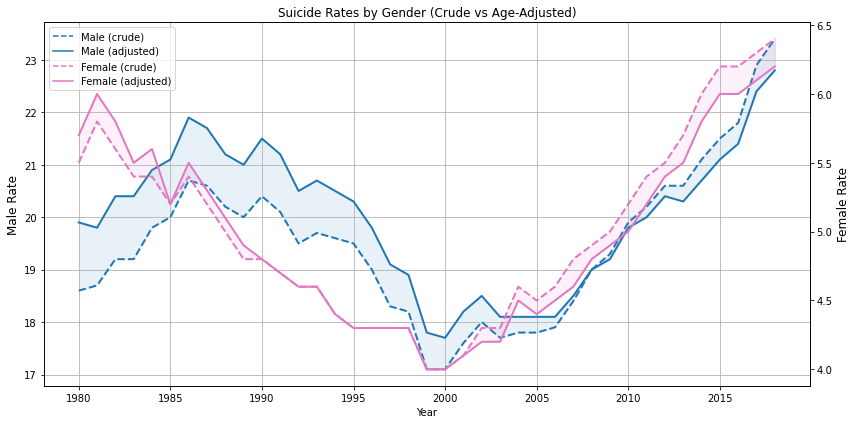

In [3]:
# --- YOUR ORIGINAL CLEANING + FILTERING ---

# Filter by STUB_NAME for sex only 
df_sex = df[df['STUB_NAME'] == 'Sex']

# Split crude and age-adjusted using UNIT
df_crude = df_sex[df_sex['UNIT'].str.contains('crude', case=False)]
df_adjusted = df_sex[df_sex['UNIT'].str.contains('age-adjusted', case=False)]

# Pivot tables for plotting
crude_pivot = df_crude.pivot_table(index='YEAR', columns='STUB_LABEL', values='ESTIMATE')
adjusted_pivot = df_adjusted.pivot_table(index='YEAR', columns='STUB_LABEL', values='ESTIMATE')

# --- 🔥 UPGRADED PLOT ---

# Set up figure and dual axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Get male and female data
crude_male = crude_pivot['Male']
crude_female = crude_pivot['Female']
adj_male = adjusted_pivot['Male']
adj_female = adjusted_pivot['Female']

# Color mapping
color_male = '#1f77b4'     # Blue
color_female = '#e377c2'   # Pink

# === Male Plot on Primary Axis ===
ax1.set_ylabel('Male Rate', size = 12)
ax1.plot(crude_male.index, crude_male, linestyle='--', linewidth=2, color=color_male, label='Male (crude)')
ax1.plot(adj_male.index, adj_male, linestyle='-', linewidth=2, color=color_male, label='Male (adjusted)')
ax1.tick_params(axis='y')

# === Female Plot on Secondary Axis ===
ax2 = ax1.twinx()
ax2.set_ylabel('Female Rate', size = 12)
ax2.plot(crude_female.index, crude_female, linestyle='--', linewidth=2, color=color_female, label='Female (crude)')
ax2.plot(adj_female.index, adj_female, linestyle='-', linewidth=2, color=color_female, label='Female (adjusted)')
ax2.tick_params(axis='y')

# === Title, axis, legend ===
plt.title('Suicide Rates by Gender (Crude vs Age-Adjusted)')
ax1.set_xlabel('Year')
ax1.grid(True)

# Custom legend combining both axes
legend_lines = [
    Line2D([0], [0], color=color_male, linestyle='--', label='Male (crude)'),
    Line2D([0], [0], color=color_male, linestyle='-', label='Male (adjusted)'),
    Line2D([0], [0], color=color_female, linestyle='--', label='Female (crude)'),
    Line2D([0], [0], color=color_female, linestyle='-', label='Female (adjusted)')
]

# Between crude and adjusted for male
ax1.fill_between(crude_male.index, crude_male, adj_male, color='#1f77b4', alpha=0.1)

# Between crude and adjusted for female
ax2.fill_between(crude_female.index, crude_female, adj_female, color='#e377c2', alpha=0.1)

ax1.legend(handles=legend_lines, loc='upper left')

plt.tight_layout()
plt.show()


# Ex3: 
merge adjuted rate andraet to one plot and splıt by age

crude age adjusted --
gender division to two plots
split by age


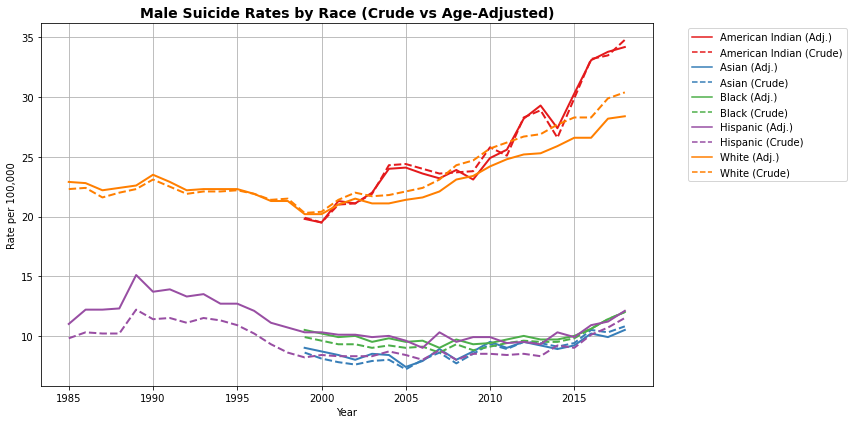

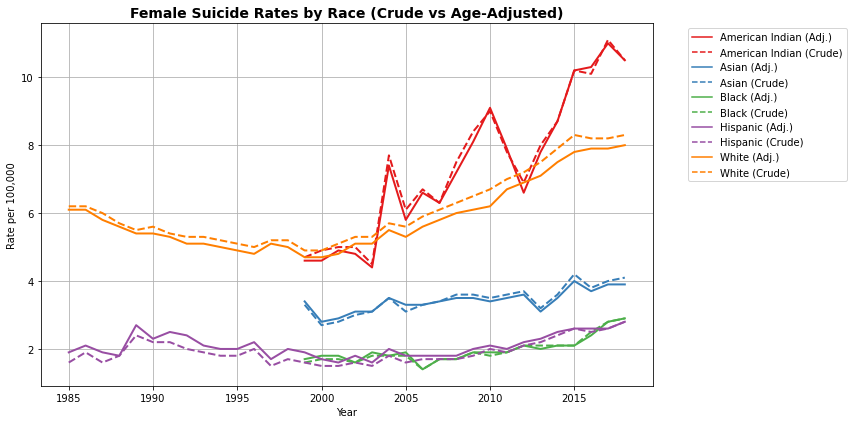

In [4]:

# === Load and clean data ===
df_gender_race = df[df['STUB_NAME'] == 'Sex and race and Hispanic origin'].copy()

# Extract Gender and Race
df_gender_race[['Gender', 'Race']] = df_gender_race['STUB_LABEL'].str.extract(r'^(Male|Female):\s*([^:]+)')

# Simplify Race name until or
df_gender_race['Race'] = df_gender_race['Race'].str.split(' or').str[0].str.strip()

# Identify Crude or Age-Adjusted
df_gender_race['RateType'] = df_gender_race['UNIT'].str.extract(r'(crude|age-adjusted)', flags=re.IGNORECASE)[0].str.title()

# Drop missing estimates
df_gender_race = df_gender_race[df_gender_race['ESTIMATE'].notna()]

# === Plotting loop: One plot for Male, one for Female ===
for gender in ['Male', 'Female']:
    df_sex = df_gender_race[df_gender_race['Gender'] == gender].copy()

    plt.figure(figsize=(12, 6))
    plt.title(f'{gender} Suicide Rates by Race (Crude vs Age-Adjusted)', fontsize=14, weight='bold')
    plt.xlabel('Year')
    plt.ylabel('Rate per 100,000')
    plt.grid(True)

    # Setup color palette
    races = sorted(df_sex['Race'].unique())
    palette = sns.color_palette('Set1', n_colors=len(races))
    color_map = dict(zip(races, palette))

    # Plot each race's lines
    for race in races:
        for rate_type, style in [('Age-Adjusted', '-'), ('Crude', '--')]:
            data = df_sex[(df_sex['Race'] == race) & (df_sex['RateType'] == rate_type)].sort_values('YEAR')
            if not data.empty:
                plt.plot(data['YEAR'], data['ESTIMATE'],
                         label=f'{race} ({rate_type})',
                         color=color_map[race],
                         linestyle=style,
                         linewidth=2)

    # Custom legend with one entry per race + line style hint
    legend_lines = []
    for race in races:
        legend_lines.append(Line2D([0], [0], color=color_map[race], linestyle='-', label=f'{race} (Adj.)'))
        legend_lines.append(Line2D([0], [0], color=color_map[race], linestyle='--', label=f'{race} (Crude)'))

    plt.legend(handles=legend_lines, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Races by aggregating the age

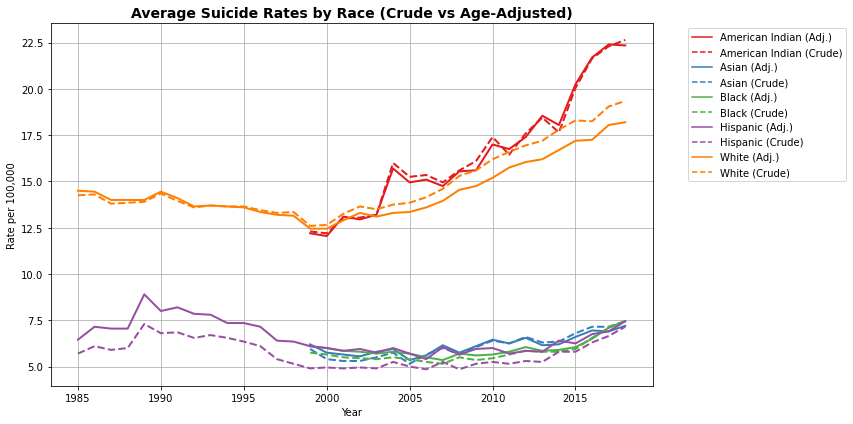

In [5]:
# === COMBINED SEXES PLOT (Assume 50/50 weighting) ===
df_combo = df_gender_race.copy()

# Group and average across genders per year, race, and rate type
df_avg = df_combo.groupby(['YEAR', 'Race', 'RateType'])['ESTIMATE'].mean().reset_index()

# === Begin plot ===
plt.figure(figsize=(12, 6))
plt.title('Average Suicide Rates by Race (Crude vs Age-Adjusted)', fontsize=14, weight='bold')
plt.xlabel('Year')
plt.ylabel('Rate per 100,000')
plt.grid(True)

# Use vibrant color palette
races = sorted(df_avg['Race'].unique())
palette = sns.color_palette('Set1', n_colors=len(races))
color_map = dict(zip(races, palette))

# Plot each race's lines
for race in races:
    for rate_type, style in [('Age-Adjusted', '-'), ('Crude', '--')]:
        data = df_avg[(df_avg['Race'] == race) & (df_avg['RateType'] == rate_type)].sort_values('YEAR')
        if not data.empty:
            plt.plot(data['YEAR'], data['ESTIMATE'],
                     label=f'{race} ({rate_type})',
                     color=color_map[race],
                     linestyle=style,
                     linewidth=2)

# Custom legend
legend_lines = []
for race in races:
    legend_lines.append(Line2D([0], [0], color=color_map[race], linestyle='-', label=f'{race} (Adj.)'))
    legend_lines.append(Line2D([0], [0], color=color_map[race], linestyle='--', label=f'{race} (Crude)'))

plt.legend(handles=legend_lines, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Ex4

bins of larger age
color for female and male

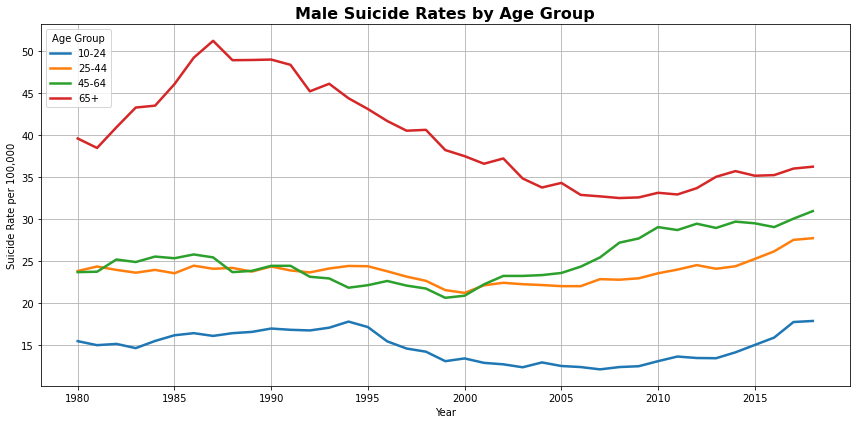

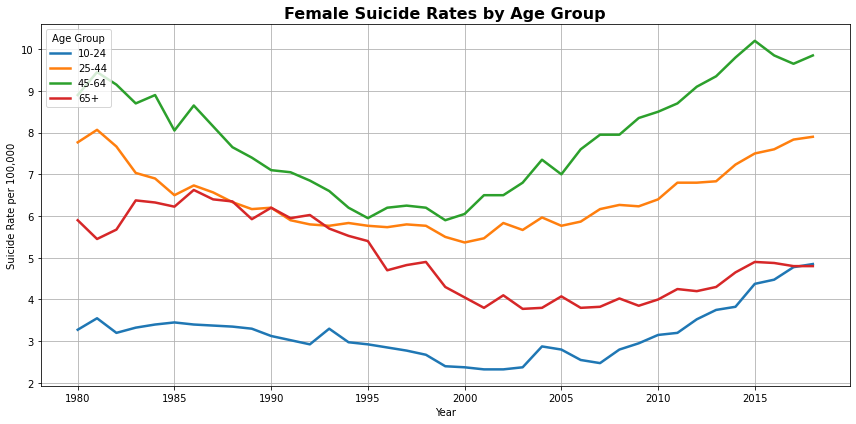

In [12]:
# === 1. Filter relevant rows ===
df_gender_age = df[(df['STUB_NAME'] == 'Sex and age') & df['UNIT'].str.contains('crude')].copy()

# === 2. Parse Gender and Age ===
df_gender_age[['Gender', 'AgeGroupRaw']] = df_gender_age['STUB_LABEL'].str.extract(r'^(Male|Female):\s*(.*)')

# === 3. Clean overlapping bins
age_bin_map = {
    '10-14 years': '10-24',
    '15-19 years': '10-24',
    '15-24 years': '10-24',
    '20-24 years': '10-24',
    '25-34 years': '25-44',
    '25-44 years': '25-44',
    '35-44 years': '25-44',
    '45-54 years': '45-64',
    '55-64 years': '45-64',
    '65-74 years': '65+',
    '65 years and over': '65+',
    '75-84 years': '65+',
    '85 years and over': '65+'
}
df_gender_age['AgeBin'] = df_gender_age['AgeGroupRaw'].map(age_bin_map)
df_gender_age = df_gender_age.dropna(subset=['AgeBin'])

# === 4. Pivot data ===
pivot = df_gender_age.pivot_table(index='YEAR', columns=['Gender', 'AgeBin'], values='ESTIMATE')

# === 5. Define vibrant colors by age bin ===
age_colors = {
    '10-24': '#1f77b4',  # blue
    '25-44': '#ff7f0e',  # orange
    '45-64': '#2ca02c',  # green
    '65+':   '#d62728'   # red
}

# === 6. Plot Male and Female separately ===
for gender, linestyle in [('Male', '-'), ('Female', '-')]:
    plt.figure(figsize=(12, 6))
    plt.title(f'{gender} Suicide Rates by Age Group', fontsize=16, weight='bold')
    
    for age_bin in sorted(age_colors.keys()):
        try:
            plt.plot(pivot.index, pivot[gender, age_bin],
                     label=age_bin,
                     color=age_colors[age_bin],
                     linestyle=linestyle,
                     linewidth=2.5)
        except KeyError:
            continue  # Skip missing combinations

    plt.xlabel('Year')
    plt.ylabel('Suicide Rate per 100,000')
    plt.grid(True)
    plt.legend(title='Age Group', loc='upper left')
    plt.tight_layout()
    plt.show()


# Ages by aggregating data

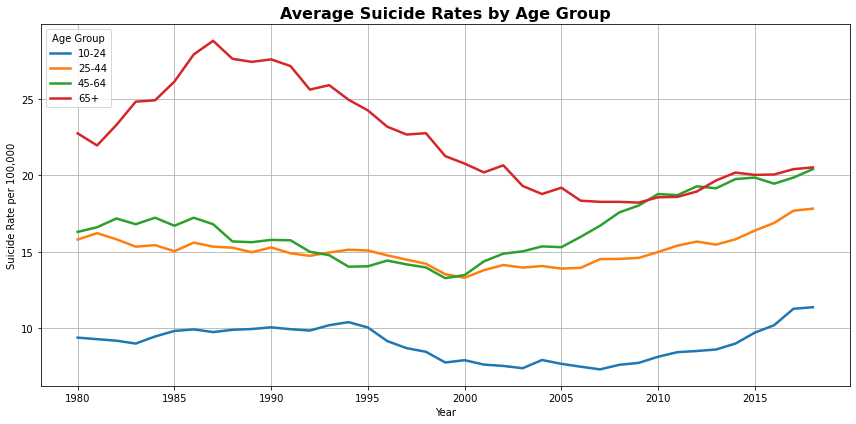

In [7]:
# === 1. Filter relevant rows ===
df_gender_age = df[(df['STUB_NAME'] == 'Sex and age') & df['UNIT'].str.contains('crude')].copy()

# === 2. Parse Gender and Age ===
df_gender_age[['Gender', 'AgeGroupRaw']] = df_gender_age['STUB_LABEL'].str.extract(r'^(Male|Female):\s*(.*)')

# === 3. Clean overlapping bins
age_bin_map = {
    '10-14 years': '10-24',
    '15-19 years': '10-24',
    '15-24 years': '10-24',
    '20-24 years': '10-24',
    '25-34 years': '25-44',
    '25-44 years': '25-44',
    '35-44 years': '25-44',
    '45-54 years': '45-64',
    '55-64 years': '45-64',
    '65-74 years': '65+',
    '65 years and over': '65+',
    '75-84 years': '65+',
    '85 years and over': '65+'
}
df_gender_age['AgeBin'] = df_gender_age['AgeGroupRaw'].map(age_bin_map)
df_gender_age = df_gender_age.dropna(subset=['AgeBin', 'ESTIMATE'])

# === 4. Average across genders ===
df_avg = df_gender_age.groupby(['YEAR', 'AgeBin'])['ESTIMATE'].mean().reset_index()

# === 5. Pivot for plotting ===
pivot_avg = df_avg.pivot(index='YEAR', columns='AgeBin', values='ESTIMATE')

# === 6. Define vibrant colors by age bin ===
age_colors = {
    '10-24': '#1f77b4',  # blue
    '25-44': '#ff7f0e',  # orange
    '45-64': '#2ca02c',  # green
    '65+':   '#d62728'   # red
}

# === 7. Plot combined line chart ===
plt.figure(figsize=(12, 6))
plt.title('Average Suicide Rates by Age Group', fontsize=16, weight='bold')

for age_bin in sorted(age_colors.keys()):
    if age_bin in pivot_avg.columns:
        plt.plot(pivot_avg.index, pivot_avg[age_bin],
                 label=age_bin,
                 color=age_colors[age_bin],
                 linewidth=2.5)

plt.xlabel('Year')
plt.ylabel('Suicide Rate per 100,000')
plt.grid(True)
plt.legend(title='Age Group', loc='upper left')
plt.tight_layout()
plt.show()


# Ex5

split by age
interpolation by marking

# indicator lines on the x axis 

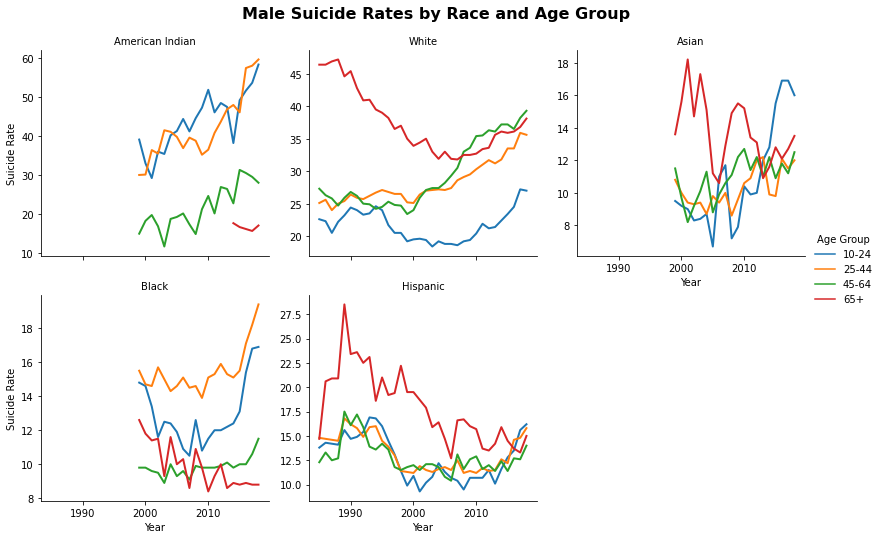

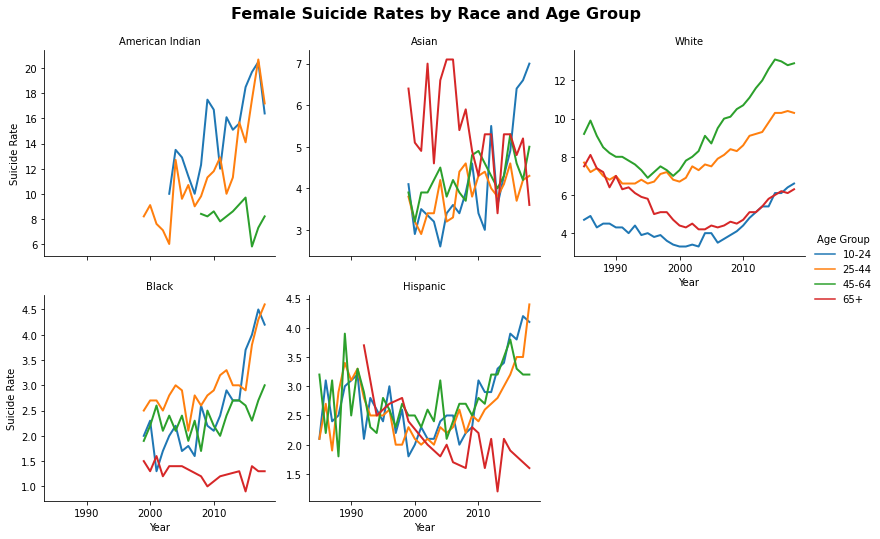

In [8]:
# === 1. Filter dataset ===
df_all = df[(df['STUB_NAME'] == 'Sex, age and race and Hispanic origin') & df['UNIT'].str.contains('crude')].copy()

# === 2. Parse properly: fix "or" race names ===
df_all[['Gender', 'Race', 'AgeGroupRaw']] = df_all['STUB_LABEL'].str.extract(r'^(Male|Female):\s*(.+?)\s*:\s*(.+)$')

# Simplify Race name until or
df_all['Race'] = df_all['Race'].str.split(' or').str[0].str.strip()

# === 3. Clean up overlapping age groups with bins ===
age_bin_map = {
    '10-14 years': '10-24',
    '15-19 years': '10-24',
    '15-24 years': '10-24',
    '20-24 years': '10-24',
    '25-34 years': '25-44',
    '25-44 years': '25-44',
    '35-44 years': '25-44',
    '45-64 years': '45-64',
    '65-74 years': '65+',
    '65 years and over': '65+',
    '75-84 years': '65+',
    '85 years and over': '65+'
}

df_all['AgeBin'] = df_all['AgeGroupRaw'].map(age_bin_map)
df_all = df_all.dropna(subset=['AgeBin', 'ESTIMATE'])

# === 4. Function to plot per gender ===
def plot_gender_facets(gender):
    subset = df_all[df_all['Gender'] == gender].copy()
    
    # Set color palette for age bins
    age_colors = {
        '10-24': '#1f77b4',
        '25-44': '#ff7f0e',
        '45-64': '#2ca02c',
        '65+': '#d62728'
    }
    
    # Set order for plots
    race_order = subset['Race'].dropna().unique()
    
    # Initialize FacetGrid
    g = sns.FacetGrid(subset, col="Race", col_wrap=3, height=3.8, sharey=False)
    
    # Plot each subplot
    g.map_dataframe(sns.lineplot, x='YEAR', y='ESTIMATE', hue='AgeBin', palette=age_colors, linewidth=2)
    
    g.set_titles("{col_name}")
    g.set_axis_labels("Year", "Suicide Rate")
    g.add_legend(title='Age Group')
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f"{gender} Suicide Rates by Race and Age Group", fontsize=16, weight='bold')

    plt.show()

# === 5. Plot separately for Male and Female ===
plot_gender_facets('Male')
plot_gender_facets('Female')


# numbers written in the heatmap, and invert for contrast

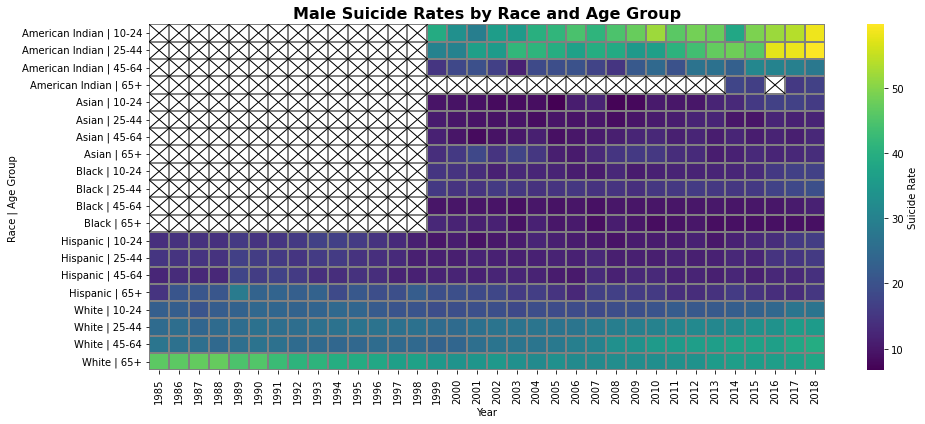

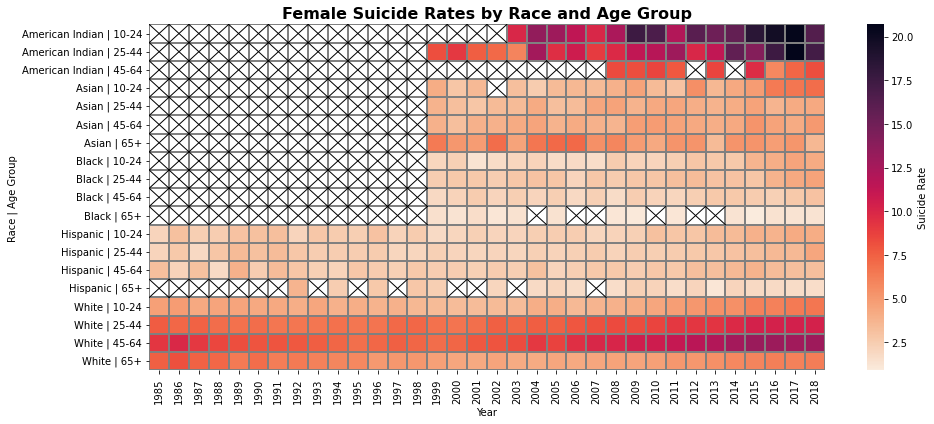

In [9]:
# === 1. Filter dataset ===
df_all = df[(df['STUB_NAME'] == 'Sex, age and race and Hispanic origin') & df['UNIT'].str.contains('crude')].copy()

# === 2. Parse labels correctly (keep full race names) ===
df_all[['Gender', 'Race', 'AgeGroupRaw']] = df_all['STUB_LABEL'].str.extract(r'^(Male|Female):\s*(.+?)\s*:\s*(.+)$')
df_all['Race'] = df_all['Race'].str.split(' or').str[0].str.strip()

# === 3. Clean up age groups
age_bin_map = {
    '10-14 years': '10-24',
    '15-19 years': '10-24',
    '15-24 years': '10-24',
    '20-24 years': '10-24',
    '25-34 years': '25-44',
    '25-44 years': '25-44',
    '35-44 years': '25-44',
    '45-64 years': '45-64',
    '65-74 years': '65+',
    '65 years and over': '65+',
    '75-84 years': '65+',
    '85 years and over': '65+'
}
df_all['AgeBin'] = df_all['AgeGroupRaw'].map(age_bin_map)
df_all = df_all.dropna(subset=['AgeBin', 'ESTIMATE'])

# === 4. Combine Race and AgeBin for row labels
df_all['Group'] = df_all['Race'] + ' | ' + df_all['AgeBin']

# === 5. Function to plot heatmap with missing-data cross overlay
def plot_heatmap(gender):
    if gender == 'Male':
        cmap = 'viridis'
    else:
        cmap = 'rocket_r'
        
    df_gender = df_all[df_all['Gender'] == gender].copy()
    
    # Pivot: rows = Group, columns = YEAR
    heatmap_data = df_gender.pivot_table(index='Group', columns='YEAR', values='ESTIMATE')
    heatmap_data = heatmap_data.sort_index()

    # Create mask for missing data
    mask = heatmap_data.isna()
    
    fig, ax = plt.subplots(figsize=(14, max(6, 0.3 * len(heatmap_data))))
    
    # Plot the heatmap
    sns.heatmap(
        heatmap_data,
        cmap=cmap,
        linewidths=0.3,
        linecolor='gray',
        annot=False,
        cbar_kws={'label': 'Suicide Rate'},
        mask=mask,
        ax=ax
    )
    
    from matplotlib.lines import Line2D

    # Overlay X's on missing cells
    for y, row in enumerate(heatmap_data.index):
        for x, col in enumerate(heatmap_data.columns):
            if pd.isna(heatmap_data.loc[row, col]):
                # Get cell center coordinates
                x0, x1 = x, x + 1
                y0, y1 = y, y + 1

                # Diagonal lines
                ax.add_line(Line2D([x0, x1], [y0, y1], color='black', linewidth=1))
                ax.add_line(Line2D([x0, x1], [y1, y0], color='black', linewidth=1))



    ax.set_title(f'{gender} Suicide Rates by Race and Age Group', fontsize=16, weight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Race | Age Group')
    plt.tight_layout()
    plt.show()

# === 6. Plot both
plot_heatmap('Male')
plot_heatmap('Female')
